In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

import torchvision.transforms as T
import spacy
from tqdm import tqdm
import random
import time

import warnings
warnings.filterwarnings("ignore")

E:\Msc\CS6421\CS6421_py_3.11\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.0.post1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


## Data Loading
This section loads the Flickr8k caption annotation file. Each row contains an image filename and one corresponding caption. Since each image has multiple captions, the loaded dataframe represents image-caption pairs rather than unique images.

In [38]:
!mkdir -p data/flickr8k/
!wget "https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_Dataset.zip" -O "data/flickr8k/Flickr8k_Dataset.zip"
!wget "https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_text.zip" -O "data/flickr8k/Flickr8k_text.zip"
!unzip -q -o "data/flickr8k/Flickr8k_Dataset.zip" -d "data/flickr8k/"
!unzip -q -o "data/flickr8k/Flickr8k_text.zip" -d "data/flickr8k/"

命令语法不正确。
'wget' 不是内部或外部命令，也不是可运行的程序
或批处理文件。
'wget' 不是内部或外部命令，也不是可运行的程序
或批处理文件。


In [2]:
data_location = "data/flickr8k"

caption_file = data_location + "/Flickr8k_text/Flickr8k.token.txt"
df = pd.read_csv(caption_file, delimiter="\t", header=None)

# Clean up filenames by removing caption index suffixes such as "#0"
df.iloc[:, 0] = df[0].apply(lambda x: x.split("#")[0])

# Keep only rows that correspond to jpg image files
df = df[df[0].apply(lambda x: x.endswith(".jpg"))]

print("Number of image-caption pairs:", len(df))
print("Number of unique images:", df[0].nunique())

Number of image-caption pairs: 40455
Number of unique images: 8091


## Creating PyTorch Dataset

### Tokenization

The first preprocessing step is to split each caption into a sequence of tokens. These tokens are later converted into numerical indices so that they can be used as inputs and targets for the caption generation model.

spaCy is used to tokenize each caption into lowercase word tokens. This keeps the text preprocessing consistent before building the vocabulary.

In [3]:
spacy_eng = spacy.load("en_core_web_sm")

### Vocabulary

The vocabulary converts caption text into integer indices that can be processed by the neural network. A frequency threshold is used so that very rare words are not added to the vocabulary. These rare or unseen words are mapped to `<UNK>`.

In [4]:
class Vocabulary:
    def __init__(self, freq_threshold):
        # Integer-to-string mapping for special tokens
        self.itos = {
            0: "<PAD>",
            1: "<SOS>",
            2: "<EOS>",
            3: "<UNK>"
        }

        # String-to-integer mapping
        self.stoi = {v: k for k, v in self.itos.items()}

        self.freq_threshold = freq_threshold

    def __len__(self):
        return len(self.itos)

    @staticmethod
    def tokenize(text):
        return [token.text.lower() for token in spacy_eng.tokenizer(text)]

    def build_vocab(self, sentence_list):
        frequencies = Counter()
        idx = 4

        for sentence in sentence_list:
            for word in self.tokenize(sentence):
                frequencies[word] += 1

                # Add the word once it reaches the minimum frequency threshold
                if frequencies[word] == self.freq_threshold:
                    self.stoi[word] = idx
                    self.itos[idx] = word
                    idx += 1

    def numericalize(self, text):
        """
        Convert a caption string into a list of token indices.
        Unknown or rare words are mapped to <UNK>.
        """
        tokenized_text = self.tokenize(text)

        return [
            self.stoi[token] if token in self.stoi else self.stoi["<UNK>"]
            for token in tokenized_text
        ]

The vocabulary contains four special tokens:   
`<PAD>` for padding captions in a batch, `<SOS>` for the start of a caption, `<EOS>` for the end of a caption, and `<UNK>` for unknown or rare words. This design keeps the vocabulary size manageable, but it may also reduce caption specificity because rare visual terms can be replaced by `<UNK>`.

### Dataset

The dataset class loads image-caption pairs, applies image transformations, and converts captions into numerical token sequences. The first 30,000 image-caption pairs are used for training, and the remaining pairs are used for validation.  
For simplicity, this project uses a row-based train/validation split. A more rigorous setup would split by unique image IDs to ensure that captions from the same image do not appear in both training and validation sets.

In [5]:
class FlickrDataset(Dataset):
    """
    PyTorch Dataset for Flickr8k image captioning.

    The dataset loads image-caption pairs, applies image transformations,
    and converts caption text into token indices.
    """
    def __init__(
        self,
        root_dir,
        captions_file,
        transform=None,
        train=True,
        vocab=None,
        freq_threshold=5,
        split_index=30000
    ):
        self.root_dir = root_dir
        self.transform = transform

        # Load caption file
        self.df = pd.read_csv(captions_file, delimiter="\t", header=None)

        # Shuffle rows for train/validation split
        np.random.seed(42)
        self.df = self.df.sample(frac=1).reset_index(drop=True)

        # Clean image filenames
        self.df.iloc[:, 0] = self.df[0].apply(lambda x: x.split("#")[0])
        self.df = self.df[self.df[0].apply(lambda x: x.endswith(".jpg"))]
        self.df = self.df.reset_index(drop=True)

        # Row-based train/validation split
        if train:
            self.df = self.df.iloc[:split_index, :].reset_index(drop=True)
        else:
            self.df = self.df.iloc[split_index:, :].reset_index(drop=True)

        # Get image names and captions after splitting
        self.imgs = self.df[0].tolist()
        self.captions = self.df[1].tolist()

        # Build vocabulary only if no vocabulary is provided
        if vocab is None:
            self.vocab = Vocabulary(freq_threshold)
            self.vocab.build_vocab(self.captions)
        else:
            self.vocab = vocab

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        caption = self.captions[idx]
        img_name = self.imgs[idx]

        img_location = os.path.join(self.root_dir, img_name)
        img = Image.open(img_location).convert("RGB")

        if self.transform is not None:
            img = self.transform(img)

        caption_vec = []
        caption_vec += [self.vocab.stoi["<SOS>"]]
        caption_vec += self.vocab.numericalize(caption)
        caption_vec += [self.vocab.stoi["<EOS>"]]

        return img, torch.tensor(caption_vec)

In [6]:
# Downscale the images, convert to Tensor
custom_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),
])

In [7]:
train_dataset = FlickrDataset(
    root_dir=data_location + "/Flicker8k_Dataset",
    captions_file=data_location + "/Flickr8k_text/Flickr8k.token.txt",
    transform=custom_transform,
    train=True,
    freq_threshold=5
)

val_dataset = FlickrDataset(
    root_dir=data_location + "/Flicker8k_Dataset",
    captions_file=data_location + "/Flickr8k_text/Flickr8k.token.txt",
    transform=custom_transform,
    train=False,
    vocab=train_dataset.vocab,
    freq_threshold=5
)

### Dataloader

Captions have different lengths, so they cannot be directly stacked into a batch. A custom collate function is used to pad all captions in the same mini-batch to the same length using the `<PAD>` token.

In [8]:
class PadCaptions:
    def __init__(self, pad_idx):
        self.pad_idx = pad_idx

    def __call__(self, batch):
        imgs = [item[0].unsqueeze(0) for item in batch]
        imgs = torch.cat(imgs, dim=0)
        targets = [item[1] for item in batch]
        targets = pad_sequence(targets, batch_first=True, padding_value=self.pad_idx)

        return imgs, targets

pad_idx = train_dataset.vocab.stoi["<PAD>"]

BATCH_SIZE=32

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    collate_fn = PadCaptions(pad_idx=pad_idx)
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    collate_fn = PadCaptions(pad_idx=pad_idx)
)

This allows the DataLoader to return image batches with shape `(batch_size, 3, 224, 224)` and caption batches with shape `(batch_size, max_caption_length)`.

In [9]:
images, captions = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Caption batch shape:", captions.shape)
print("Vocabulary size:", len(train_dataset.vocab))

Image batch shape: torch.Size([32, 3, 224, 224])
Caption batch shape: torch.Size([32, 25])
Vocabulary size: 2568


## Part 2: Custom CNN Encoder + Transformer Decoder Baseline

This section defines the baseline image captioning model. A small custom CNN is used as the image encoder, and a Transformer decoder is used to generate captions token by token. The purpose of this baseline is to provide a simple reference model before introducing a pretrained ResNet encoder.

### Custom CNN Encoder

The encoder converts each input image into a fixed-length feature vector. This feature vector is later used as the visual memory for the Transformer decoder. Since this CNN is trained from scratch, it provides a simple but relatively weak visual representation compared with pretrained CNN backbones.

In [10]:
class EncoderCNN(nn.Module):
    def __init__(self, embed_size):
        super(EncoderCNN, self).__init__()
        # Layer 1: Input (3, 224, 224) -> Output (32, 112, 112)
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)

        # Layer 2: Output (64, 56, 56)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)

        # Layer 3: Output (128, 28, 28)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(2, 2)

        # Fully connected layer to reach embed_size
        # Assuming input image is 224x224, after 3 pools it is 28x28
        self.fc = nn.Linear(128 * 28 * 28, embed_size)
        self.dropout = nn.Dropout(0.5)

    def forward(self, images):
        x = self.pool1(F.relu(self.conv1(images)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = self.pool3(F.relu(self.conv3(x)))

        # Flatten the features
        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc(x)))
        return x

### Transformer Decoder

The Transformer decoder uses the image feature vector as memory and the caption tokens as the target sequence. During training, the input caption excludes the final token, and the model predicts the next token at each position. A causal mask prevents the decoder from using future words during prediction.

In [11]:
class DecoderTransformer(nn.Module):
    def __init__(self, embed_size, vocab_size, num_heads=8, num_layers=4, dropout=0.1):
        super(DecoderTransformer, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        
        # Transformer Decoder Layer
        # We use a standard TransformerDecoder to replace the LSTM
        decoder_layer = nn.TransformerDecoderLayer(
            d_model=embed_size, 
            nhead=num_heads, 
            dim_feedforward=embed_size * 4, 
            dropout=dropout,
            batch_first=True
        )
        self.transformer_decoder = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)
        
        self.linear = nn.Linear(embed_size, vocab_size)

    def forward(self, features, captions):
        """
        features: (batch, embed_size) - from CNN
        captions: (batch, seq_len)
        """
        # Embed the captions (excluding <end> token)
        # captions: [batch, seq_len-1] -> [batch, seq_len-1, embed_size]
        tgt = self.embedding(captions[:, :-1])
               
        # In Transformers, we treat the image feature as the 'memory' (encoder output)
        # Transforms expect a rank 3 tensor, so we need to add an aaddtional
        # dummy dimension : (batch, 1, embed_size)
        memory = features.unsqueeze(1)
        
        # Create a causal mask for the captions (to prevent looking at the future)
        # This stops the Transformer from "cheating" by "looking" at the word it is supposed
        # to be predicting. Do
        tgt_mask = nn.Transformer.generate_square_subsequent_mask(tgt.size(1)).to(tgt.device)
        # Pass through the Transformer Decoder
        # The decoder uses caption embeddings as 'tgt' and image features as 'memory'
        output = self.transformer_decoder(tgt, memory, tgt_mask=tgt_mask)
        
        return self.linear(output)

In this architecture, the CNN encoder converts an image into a feature vector. The Transformer decoder then uses this image feature together with the previously generated caption tokens to predict the next word.  
A limitation of this baseline is that the entire image is compressed into a single global feature vector, which may lose spatial and object-level details.

## Training Loop

### Greedy Decoding for Caption Generation
Greedy decoding is used to generate captions from a trained model. Starting with the `<SOS>` token, the decoder repeatedly predicts the most likely next token. The generated token is then appended to the input sequence for the next step. This continues until `<EOS>` is generated or the maximum length is reached.

In [12]:
def generate_caption(encoder, decoder, image, vocab, max_length=20):
    encoder.eval()
    decoder.eval()

    result_caption = []

    with torch.no_grad():
        # 1. Process Image
        # image shape: [3, 224, 224] -> [1, 3, 224, 224]
        x = image.unsqueeze(0).to(DEVICE)
        features = encoder(x) # [1, embed_size]
        # Memory for transformer is the image feature
        memory = features.unsqueeze(1) # [1, 1, embed_size]

        # 2. Initialize sequence with <SOS> token
        sos_idx = vocab.stoi["<SOS>"]
        eos_idx = vocab.stoi["<EOS>"]

        # current_indices keeps track of the sequence generated so far
        current_indices = torch.tensor([[sos_idx]], device=DEVICE) # Shape: [1, 1]

        for _ in range(max_length):
            # Embed the sequence generated so far
            tgt = decoder.embedding(current_indices) # Shape: [1, seq_len, embed_size]

            # Create a causal mask for the current length
            tgt_mask = nn.Transformer.generate_square_subsequent_mask(current_indices.size(1)).to(DEVICE)

            # Pass to Transformer Decoder
            # memory is the static image feature; tgt is the growing caption
            output = decoder.transformer_decoder(tgt, memory, tgt_mask=tgt_mask)

            # Predict the NEXT word using the last position of the output
            # output shape: [1, seq_len, embed_size] -> take [:, -1, :]
            logits = decoder.linear(output[:, -1, :]) # Shape: [1, vocab_size]
            predicted = logits.argmax(1)

            # Update the sequence for the next iteration
            current_indices = torch.cat((current_indices, predicted.unsqueeze(0)), dim=1)

            token = vocab.itos[predicted.item()]
            if token == "<EOS>":
                break

            result_caption.append(token)

    return ' '.join(result_caption)

Greedy decoding is simple and fast, but it only keeps the single most likely token at each step. This can produce suboptimal captions because the locally best word at one step may not lead to the best full sentence. This motivates the later comparison with beam search decoding.

## Evaluation Metrics

This section defines helper functions for evaluating generated captions. BLEU is used to measure n-gram overlap between generated and reference captions, while ROUGE-L measures the longest common subsequence between them.

Before computing these metrics, special tokens such as `<SOS>`, `<EOS>`, and `<PAD>` are removed so that evaluation focuses only on the generated caption content.

In [13]:
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

def clean_tokens(tokens):
    """
    Remove special tokens from a token list.
    """
    special_tokens = {"<SOS>", "<EOS>", "<PAD>"}
    return [token for token in tokens if token not in special_tokens]


def caption_tensor_to_tokens(caption_tensor, vocab):
    """
    Convert a numericalized caption tensor back to word tokens.
    """
    tokens = []

    for idx in caption_tensor.tolist():
        word = vocab.itos[idx]
        if word == "<EOS>":
            break
        if word not in ["<SOS>", "<PAD>"]:
            tokens.append(word)

    return tokens


def lcs_length(x, y):
    """
    Compute the length of the longest common subsequence.
    Used for ROUGE-L.
    """
    m, n = len(x), len(y)
    dp = [[0] * (n + 1) for _ in range(m + 1)]

    for i in range(m):
        for j in range(n):
            if x[i] == y[j]:
                dp[i + 1][j + 1] = dp[i][j] + 1
            else:
                dp[i + 1][j + 1] = max(dp[i][j + 1], dp[i + 1][j])

    return dp[m][n]


def rouge_l_score(reference, candidate):
    """
    Compute ROUGE-L F1 score for one reference and one candidate.
    """
    if len(reference) == 0 or len(candidate) == 0:
        return 0.0

    lcs = lcs_length(reference, candidate)

    precision = lcs / len(candidate)
    recall = lcs / len(reference)

    if precision + recall == 0:
        return 0.0

    return 2 * precision * recall / (precision + recall)

BLEU-1 mainly reflects word-level overlap, while BLEU-4 is stricter because it requires longer phrase-level overlap. ROUGE-L is useful for checking whether the generated caption follows a similar word order to the reference caption.

### Beam Search Decoding

Greedy decoding selects only the most likely token at each time step. This can be limiting because the best local choice may not lead to the best full sentence.

Beam search keeps multiple candidate captions during generation. At each step, the top candidate sequences are expanded and ranked using their accumulated log probabilities. A length penalty is used to avoid overly short captions, and repeated n-grams are blocked to reduce repetitive phrases.

In [14]:
def generate_caption_beam_search(
    encoder,
    decoder,
    image,
    vocab,
    beam_size=3,
    max_length=20,
    length_penalty=0.7,
    no_repeat_ngram_size=2
):
    """
    Generate a caption using beam search decoding.
    
    A dummy `<PAD>` token is appended at each step because the decoder forward pass
    uses `captions[:, :-1]` internally. This allows the final output position to
    predict the next token.
    """
    encoder.eval()
    decoder.eval()

    sos_idx = vocab.stoi["<SOS>"]
    eos_idx = vocab.stoi["<EOS>"]
    pad_idx = vocab.stoi["<PAD>"]

    with torch.no_grad():
        x = image.unsqueeze(0).to(DEVICE)
        features = encoder(x)

        beams = [([sos_idx], 0.0)]
        completed_beams = []

        for _ in range(max_length):
            new_beams = []

            for seq, score in beams:
                if seq[-1] == eos_idx:
                    completed_beams.append((seq, score))
                    continue

                # Append a dummy token.
                # Because decoder.forward() uses captions[:, :-1],
                # this makes the decoder condition on the full current sequence.
                decoder_seq = seq + [pad_idx]

                caption_tensor = torch.tensor(
                    decoder_seq,
                    dtype=torch.long
                ).unsqueeze(0).to(DEVICE)

                outputs = decoder(features, caption_tensor)

                # Last output predicts the next token after seq
                last_logits = outputs[:, -1, :]

                log_probs = F.log_softmax(last_logits, dim=-1)

                # Avoid generating special tokens except EOS
                log_probs[:, sos_idx] = -float("inf")
                log_probs[:, pad_idx] = -float("inf")

                top_log_probs, top_indices = torch.topk(
                    log_probs,
                    beam_size,
                    dim=-1
                )

                for i in range(beam_size):
                    next_word_idx = top_indices[0, i].item()
                    next_word_log_prob = top_log_probs[0, i].item()

                    new_seq = seq + [next_word_idx]

                    # Optional: prevent repeated bigrams
                    if no_repeat_ngram_size is not None and no_repeat_ngram_size > 0:
                        words = new_seq
                        if len(words) >= 2 * no_repeat_ngram_size:
                            last_ngram = tuple(words[-no_repeat_ngram_size:])
                            previous_ngrams = [
                                tuple(words[j:j + no_repeat_ngram_size])
                                for j in range(len(words) - no_repeat_ngram_size)
                            ]

                            if last_ngram in previous_ngrams:
                                continue

                    new_score = score + next_word_log_prob
                    new_beams.append((new_seq, new_score))

            if len(new_beams) == 0:
                break

            def normalised_score(beam):
                seq, score = beam
                return score / (len(seq) ** length_penalty)

            new_beams = sorted(
                new_beams,
                key=normalised_score,
                reverse=True
            )

            beams = new_beams[:beam_size]

        completed_beams.extend(beams)

        def final_score(beam):
            seq, score = beam
            return score / (len(seq) ** length_penalty)

        best_seq, best_score = max(completed_beams, key=final_score)

    caption = []

    for idx in best_seq:
        word = vocab.itos[idx]

        if word in ["<SOS>", "<PAD>"]:
            continue

        if word == "<EOS>":
            break

        caption.append(word)

    return caption

Beam search does not change the trained model parameters. It only changes the decoding strategy at inference time. Therefore, any improvement from beam search shows that the generation procedure itself affects caption quality.

### Metric Evaluation Function

The `evaluate_caption_metrics` function generates captions for a subset of the validation set and compares them with the reference captions. It supports both greedy decoding and beam search decoding, which makes it possible to compare different decoding strategies using the same evaluation pipeline.

Only a fixed number of validation samples is used for faster evaluation.

In [15]:
def evaluate_caption_metrics(
    encoder,
    decoder,
    val_dataset,
    vocab,
    max_samples=500,
    decoding_method="greedy",
    beam_size=3,
    length_penalty=0.7,
    max_length=20
):
    """
    Evaluate generated captions using BLEU and ROUGE-L.

    decoding_method:
        "greedy" or "beam"
    """
    encoder.eval()
    decoder.eval()

    references = []
    candidates = []
    rouge_l_scores = []

    smoothie = SmoothingFunction().method4

    num_samples = min(max_samples, len(val_dataset))
    
    for i in range(num_samples):
        image, caption = val_dataset[i]

        if decoding_method == "greedy":
            predicted_caption = generate_caption(
                encoder=encoder,
                decoder=decoder,
                image=image,
                vocab=vocab,
                max_length=max_length
            )

        elif decoding_method == "beam":
            predicted_caption = generate_caption_beam_search(
                encoder=encoder,
                decoder=decoder,
                image=image,
                vocab=vocab,
                beam_size=beam_size,
                max_length=max_length,
                length_penalty=length_penalty
            )

        else:
            raise ValueError("decoding_method must be 'greedy' or 'beam'.")

        if isinstance(predicted_caption, str):
            predicted_caption = predicted_caption.split()
        candidate_tokens = clean_tokens(predicted_caption)
        reference_tokens = caption_tensor_to_tokens(caption, vocab)

        if len(candidate_tokens) == 0 or len(reference_tokens) == 0:
            continue

        references.append([reference_tokens])
        candidates.append(candidate_tokens)

        rouge_l_scores.append(
            rouge_l_score(reference_tokens, candidate_tokens)
        )

    bleu_1 = corpus_bleu(
        references,
        candidates,
        weights=(1.0, 0, 0, 0),
        smoothing_function=smoothie
    )

    bleu_2 = corpus_bleu(
        references,
        candidates,
        weights=(0.5, 0.5, 0, 0),
        smoothing_function=smoothie
    )

    bleu_3 = corpus_bleu(
        references,
        candidates,
        weights=(1/3, 1/3, 1/3, 0),
        smoothing_function=smoothie
    )

    bleu_4 = corpus_bleu(
        references,
        candidates,
        weights=(0.25, 0.25, 0.25, 0.25),
        smoothing_function=smoothie
    )

    rouge_l = np.mean(rouge_l_scores)

    results = {
        "BLEU-1": bleu_1,
        "BLEU-2": bleu_2,
        "BLEU-3": bleu_3,
        "BLEU-4": bleu_4,
        "ROUGE-L": rouge_l
    }

    return results

This function provides quantitative scores, but these scores should be interpreted together with qualitative examples. BLEU and ROUGE-L measure lexical overlap, so a caption can receive a higher score even if it still misses important visual details.

## Training the Custom CNN + Transformer Baseline

This experiment trains the baseline image captioning model using the custom CNN encoder and Transformer decoder. The objective is next-token prediction: given the image feature and the previous caption tokens, the model predicts the next word in the caption.

Cross-entropy loss is used, and `<PAD>` tokens are ignored so that padded positions do not contribute to the loss. Training and validation losses are recorded after each epoch to monitor convergence.

In [16]:
# Hyperparameters for the custom CNN baseline
EMBED_SIZE = 64
NUM_EPOCHS = 5
LEARNING_RATE = 1e-4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

vocab = train_dataset.vocab
VOCAB_SIZE = len(vocab)
PAD_IDX = vocab.stoi["<PAD>"]

# Reproducibility
seed = 6421
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

# Initialize baseline models
encoder = EncoderCNN(EMBED_SIZE).to(DEVICE)
decoder = DecoderTransformer(EMBED_SIZE, VOCAB_SIZE).to(DEVICE)

# Loss and optimizer
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
params = list(encoder.parameters()) + list(decoder.parameters())
optimizer = torch.optim.Adam(params, lr=LEARNING_RATE)

train_losses = []
val_losses = []

start_time = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    # Training phase
    encoder.train()
    decoder.train()

    total_train_loss = 0.0

    loop = tqdm(train_loader, total=len(train_loader), leave=True)

    for images, captions in loop:
        images = images.to(DEVICE)
        captions = captions.to(DEVICE)

        optimizer.zero_grad()

        features = encoder(images)
        outputs = decoder(features, captions)

        # The decoder predicts tokens after <SOS>
        targets = captions[:, 1:]

        loss = criterion(
            outputs.reshape(-1, VOCAB_SIZE),
            targets.reshape(-1)
        )

        loss.backward()

        # Gradient clipping helps stabilise training
        torch.nn.utils.clip_grad_norm_(params, max_norm=5)

        optimizer.step()

        total_train_loss += loss.item()

        loop.set_description(f"Epoch [{epoch}/{NUM_EPOCHS}]")
        loop.set_postfix(loss=loss.item())

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation phase
    encoder.eval()
    decoder.eval()

    total_val_loss = 0.0

    with torch.no_grad():
        for images, captions in val_loader:
            images = images.to(DEVICE)
            captions = captions.to(DEVICE)

            features = encoder(images)
            outputs = decoder(features, captions)

            targets = captions[:, 1:]

            loss = criterion(
                outputs.reshape(-1, VOCAB_SIZE),
                targets.reshape(-1)
            )

            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"\n=> Epoch {epoch} Complete")
    print(f"   Avg Train Loss: {avg_train_loss:.4f}")
    print(f"   Avg Val Loss:   {avg_val_loss:.4f}")

elapsed_time = time.time() - start_time
print(f"Total training time: {elapsed_time:.2f} s")

baseline_results = [{
    "Model": "Custom CNN + Transformer",
    "Embedding size": EMBED_SIZE,
    "Average train loss": avg_train_loss,
    "Average val loss": avg_val_loss,
    "Training time (s)": elapsed_time
}]

Epoch [1/5]: 100%|█████████████████████████████████████████████████████████| 938/938 [01:47<00:00,  8.74it/s, loss=4.2]



=> Epoch 1 Complete
   Avg Train Loss: 5.1274
   Avg Val Loss:   4.2071


Epoch [2/5]: 100%|█████████████████████████████████████████████████████████| 938/938 [01:48<00:00,  8.64it/s, loss=4.2]



=> Epoch 2 Complete
   Avg Train Loss: 4.0250
   Avg Val Loss:   3.7932


Epoch [3/5]: 100%|████████████████████████████████████████████████████████| 938/938 [01:48<00:00,  8.65it/s, loss=3.93]



=> Epoch 3 Complete
   Avg Train Loss: 3.7359
   Avg Val Loss:   3.5918


Epoch [4/5]: 100%|████████████████████████████████████████████████████████| 938/938 [01:49<00:00,  8.59it/s, loss=3.17]



=> Epoch 4 Complete
   Avg Train Loss: 3.5639
   Avg Val Loss:   3.4476


Epoch [5/5]: 100%|████████████████████████████████████████████████████████| 938/938 [01:51<00:00,  8.44it/s, loss=3.57]



=> Epoch 5 Complete
   Avg Train Loss: 3.4423
   Avg Val Loss:   3.3459
Total training time: 689.87 s


The training and validation losses are stored for plotting learning curves. These curves are used to check whether the model is learning, underfitting, or overfitting.

## Training Curves

Training and validation losses are plotted to monitor whether the baseline model is learning properly. The training loss measures how well the model fits the training captions, while the validation loss gives an indication of generalisation to unseen image-caption pairs.

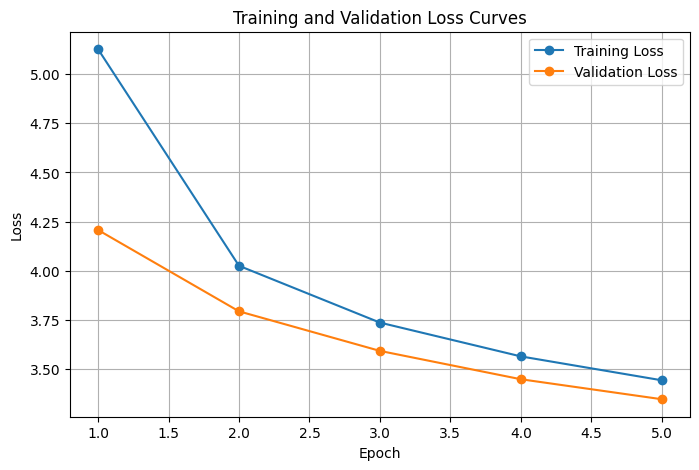

In [17]:
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, marker="o", label="Training Loss")
plt.plot(epochs, val_losses, marker="o", label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss Curves")
plt.legend()
plt.grid(True)
plt.show()

Both training and validation losses decrease over the five epochs, which indicates that the model is learning useful patterns rather than failing to train. The validation loss also decreases instead of increasing, so there is no strong evidence of overfitting in this short training run.

However, decreasing cross-entropy loss does not necessarily mean that the generated captions are semantically accurate. The model may still learn frequent caption patterns without correctly grounding the caption in image-specific details.

In [18]:
def unnormalize_image(image, mean, std):
    """
    Undo image normalization for visualization.
    """
    image = image.clone().detach().cpu()

    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)

    image = image * std + mean
    image = image.clamp(0, 1)

    return image

## Qualitative Examples from the Baseline Model

In addition to loss curves, generated captions are inspected qualitatively. This helps reveal whether the model is actually describing image content or simply producing common caption patterns.

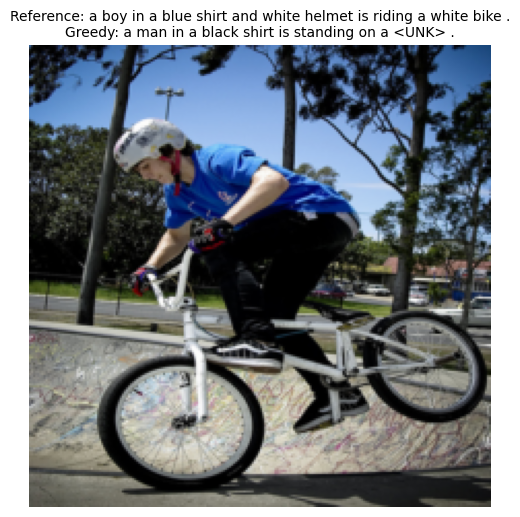

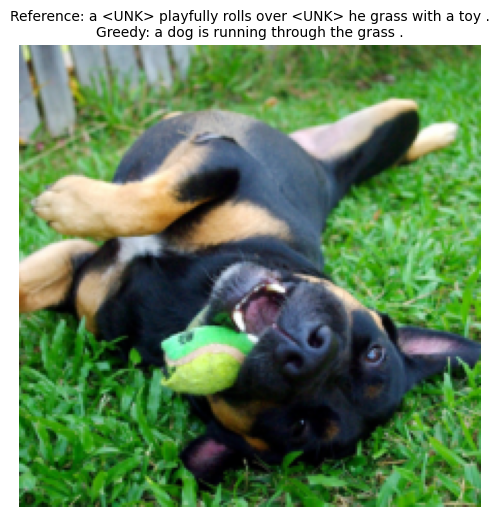

In [19]:
# Show qualitative examples from the validation set
encoder.eval()
decoder.eval()

images, captions = next(iter(val_loader))

num_examples = min(2, len(images))

custom_mean = [0.485, 0.456, 0.406]
custom_std = [0.229, 0.224, 0.225]

for i in range(num_examples):
    sample_img = images[i]
    sample_cap = captions[i]

    # Generate greedy prediction
    prediction = generate_caption(
        encoder=encoder,
        decoder=decoder,
        image=sample_img,
        vocab=vocab,
        max_length=20
    )

    # Convert ground-truth caption tensor back to tokens
    reference_tokens = [
        vocab.itos[idx.item()]
        for idx in sample_cap
        if vocab.itos[idx.item()] not in ["<PAD>", "<SOS>", "<EOS>"]
    ]

    reference = " ".join(reference_tokens)

    # Unnormalize image for display
    img = unnormalize_image(
        sample_img,
        mean=custom_mean,
        std=custom_std
    ).permute(1, 2, 0).numpy()

    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.title(
        "Reference: " + reference + "\n" +
        "Greedy: " + prediction,
        fontsize=10
    )
    plt.show()

The baseline model can generate grammatically simple captions and sometimes captures high-level visual concepts such as clothing colour, people, dogs, or grass. However, the predictions still miss important image-specific details. For example, the model may identify a person but fail to describe the correct action or object, such as riding a bike. This suggests that the custom CNN encoder and greedy decoding strategy provide a working baseline, but they are still limited for fine-grained image captioning.

## Quantitative Evaluation of the Baseline Model

After inspecting qualitative examples, the baseline model is evaluated using BLEU and ROUGE-L. These metrics measure lexical overlap between generated captions and reference captions. They provide a quantitative summary of caption quality, but they should be interpreted together with qualitative examples because word overlap does not always reflect semantic correctness.

In [20]:
custom_cnn_greedy_metrics = evaluate_caption_metrics(
    encoder=encoder,
    decoder=decoder,
    val_dataset=val_dataset,
    vocab=train_dataset.vocab,
    max_samples=500,
    decoding_method="greedy"
)

pd.DataFrame({
    "Custom CNN + Greedy": custom_cnn_greedy_metrics
})

,Custom CNN + Greedy
BLEU-1,0.339477
BLEU-2,0.155059
BLEU-3,0.076271
BLEU-4,0.042641
ROUGE-L,0.325185


The baseline model obtains low BLEU and ROUGE-L scores. BLEU-1 is higher than BLEU-2 to BLEU-4, which means the model can sometimes predict individual relevant words, but it struggles to generate longer phrase-level matches with the reference captions. This is consistent with the qualitative examples: the model captures some high-level concepts but often misses detailed objects, actions, or scene information.

## ResNet18 Encoder + Transformer Decoder

The custom CNN baseline produced valid but limited captions. To improve the visual representation, the custom CNN encoder is replaced with a pretrained ResNet18 encoder. The Transformer decoder is kept unchanged so that this experiment mainly tests the effect of using stronger pretrained image features.

In this experiment, the ResNet18 backbone is frozen and only the projection layer, batch normalization layer, and Transformer decoder are trained. This keeps training lightweight and reduces the risk of overfitting on the relatively small Flickr8k dataset.

In [21]:
import torchvision.models as models
from torchvision.models import ResNet18_Weights

### Pretrained ResNet18 Encoder

ResNet18 was pretrained on ImageNet, so it already contains useful visual features such as edges, textures, object parts, and high-level image patterns. Instead of training a CNN from scratch, this encoder reuses the pretrained ResNet backbone and projects its 512-dimensional output into the Transformer embedding size.

In [22]:
class ResNetEncoder(nn.Module):
    """
    Pretrained ResNet18 encoder for image captioning.

    The ResNet backbone extracts visual features from the input image.
    The final classification layer is removed, and the extracted feature
    vector is projected to the Transformer embedding size.
    """
    def __init__(self, embed_size, train_cnn=False):
        super(ResNetEncoder, self).__init__()

        # Load pretrained ResNet18
        weights = ResNet18_Weights.DEFAULT
        resnet = models.resnet18(weights=weights)

        # Remove the final fully connected classification layer
        # Original ResNet18:
        # conv layers -> avgpool -> fc
        # We keep everything before fc.
        self.resnet = nn.Sequential(*list(resnet.children())[:-1])

        # Freeze ResNet parameters by default
        for param in self.resnet.parameters():
            param.requires_grad = train_cnn

        # ResNet18 outputs a 512-dimensional feature vector
        self.fc = nn.Linear(512, embed_size)

        # Optional normalization and dropout
        self.bn = nn.BatchNorm1d(embed_size)
        self.dropout = nn.Dropout(0.3)

    def forward(self, images):
        """
        images: (batch, 3, H, W)
        returns: (batch, embed_size)
        """

        # Extract ResNet features
        # Output shape: (batch, 512, 1, 1)
        features = self.resnet(images)

        # Flatten to: (batch, 512)
        features = features.view(features.size(0), -1)

        # Project to Transformer embedding size
        features = self.fc(features)

        # Normalise and regularise projected features
        features = self.bn(features)
        features = self.dropout(features)

        return features

The encoder still compresses the whole image into a single global feature vector. This is simple and compatible with the existing Transformer decoder, but it may lose spatial details such as object locations, interactions, and counts.

### Image Transform for ResNet18

The pretrained ResNet18 model expects images to be resized to `224 × 224` and normalized using ImageNet mean and standard deviation. Therefore, a separate transform pipeline is used for the ResNet experiment.

In [23]:
transform_Res = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),
])

In [24]:
train_dataset_res = FlickrDataset(
    root_dir=data_location + "/Flicker8k_Dataset",
    captions_file=data_location + "/Flickr8k_text/Flickr8k.token.txt",
    transform=transform_Res,
    train=True,
    freq_threshold=5
)

val_dataset_res = FlickrDataset(
    root_dir=data_location + "/Flicker8k_Dataset",
    captions_file=data_location + "/Flickr8k_text/Flickr8k.token.txt",
    train=False,
    transform=transform_Res,
    vocab=train_dataset_res.vocab,
    freq_threshold=5
)

## Training the ResNet18 + Transformer Model

This experiment uses the same Transformer decoder as the baseline model, but replaces the custom CNN encoder with a pretrained ResNet18 encoder. The ResNet backbone is frozen, so only the projection layer, batch normalization layer, and Transformer decoder are updated during training.

The goal is to test whether stronger pretrained visual features improve caption generation compared with the custom CNN baseline.

In [25]:
# Hyperparameters for the ResNet18 experiment
EMBED_SIZE = 64
NUM_EPOCHS = 5
LEARNING_RATE = 1e-4
BATCH_SIZE = 32
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

vocab = train_dataset_res.vocab
VOCAB_SIZE = len(vocab)
PAD_IDX = vocab.stoi["<PAD>"]

# Create dataloaders for the ResNet transform pipeline
train_loader_res = DataLoader(
    dataset=train_dataset_res,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    collate_fn=PadCaptions(pad_idx=PAD_IDX)
)

val_loader_res = DataLoader(
    dataset=val_dataset_res,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    collate_fn=PadCaptions(pad_idx=PAD_IDX)
)

# Reproducibility
seed = 6421
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

# Initialize ResNet18 encoder and Transformer decoder
encoder = ResNetEncoder(
    embed_size=EMBED_SIZE,
    train_cnn=False
).to(DEVICE)

decoder = DecoderTransformer(
    EMBED_SIZE,
    VOCAB_SIZE
).to(DEVICE)

criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

# Only train the projection layer, batch norm layer, and decoder
params = (
    list(encoder.fc.parameters()) +
    list(encoder.bn.parameters()) +
    list(decoder.parameters())
)

optimizer = torch.optim.Adam(params, lr=LEARNING_RATE)

Before training, a batch is passed through the ResNet encoder to verify that the encoder output shape matches the Transformer decoder input requirement.

In [26]:
image_batch, caption_batch = next(iter(train_loader_res))
image_batch = image_batch.to(DEVICE)

features = encoder(image_batch)

print("Image batch shape:", image_batch.shape)
print("Encoded feature shape:", features.shape)

Image batch shape: torch.Size([32, 3, 224, 224])
Encoded feature shape: torch.Size([32, 64])


In [27]:
train_losses_res = []
val_losses_res = []

start_time = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    encoder.train()
    decoder.train()

    total_train_loss = 0.0

    loop = tqdm(train_loader_res, total=len(train_loader_res), leave=True)

    for images, captions in loop:
        images = images.to(DEVICE)
        captions = captions.to(DEVICE)

        optimizer.zero_grad()

        features = encoder(images)
        outputs = decoder(features, captions)

        targets = captions[:, 1:]

        loss = criterion(
            outputs.reshape(-1, VOCAB_SIZE),
            targets.reshape(-1)
        )

        loss.backward()
        torch.nn.utils.clip_grad_norm_(params, max_norm=5)
        optimizer.step()

        total_train_loss += loss.item()

        loop.set_description(f"Epoch [{epoch}/{NUM_EPOCHS}]")
        loop.set_postfix(loss=loss.item())

    avg_train_loss = total_train_loss / len(train_loader_res)
    train_losses_res.append(avg_train_loss)

    encoder.eval()
    decoder.eval()

    total_val_loss = 0.0

    with torch.no_grad():
        for images, captions in val_loader_res:
            images = images.to(DEVICE)
            captions = captions.to(DEVICE)

            features = encoder(images)
            outputs = decoder(features, captions)

            targets = captions[:, 1:]

            loss = criterion(
                outputs.reshape(-1, VOCAB_SIZE),
                targets.reshape(-1)
            )

            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(val_loader_res)
    val_losses_res.append(avg_val_loss)

    print(f"\n=> Epoch {epoch} Complete")
    print(f"   Avg Train Loss: {avg_train_loss:.4f}")
    print(f"   Avg Val Loss:   {avg_val_loss:.4f}")

elapsed_time = time.time() - start_time
print(f"Total training time: {elapsed_time:.2f} s")

resnet_results = [{
    "Model": "ResNet18 + Transformer",
    "Embedding size": EMBED_SIZE,
    "Average train loss": avg_train_loss,
    "Average val loss": avg_val_loss,
    "Training time (s)": elapsed_time
}]

Epoch [1/5]: 100%|████████████████████████████████████████████████████████| 938/938 [01:44<00:00,  8.99it/s, loss=4.51]



=> Epoch 1 Complete
   Avg Train Loss: 5.2874
   Avg Val Loss:   4.3177


Epoch [2/5]: 100%|████████████████████████████████████████████████████████| 938/938 [01:43<00:00,  9.04it/s, loss=3.95]



=> Epoch 2 Complete
   Avg Train Loss: 4.1221
   Avg Val Loss:   3.8353


Epoch [3/5]: 100%|████████████████████████████████████████████████████████| 938/938 [01:43<00:00,  9.02it/s, loss=3.85]



=> Epoch 3 Complete
   Avg Train Loss: 3.7788
   Avg Val Loss:   3.5843


Epoch [4/5]: 100%|████████████████████████████████████████████████████████| 938/938 [01:44<00:00,  8.95it/s, loss=3.39]



=> Epoch 4 Complete
   Avg Train Loss: 3.5742
   Avg Val Loss:   3.4160


Epoch [5/5]: 100%|████████████████████████████████████████████████████████| 938/938 [01:44<00:00,  9.01it/s, loss=3.52]



=> Epoch 5 Complete
   Avg Train Loss: 3.4351
   Avg Val Loss:   3.3012
Total training time: 667.86 s


## Training Curves for the ResNet18 Model

The ResNet18-based model is trained using the same Transformer decoder as the custom CNN baseline. The training and validation losses are plotted to check whether the model continues to learn properly after replacing the encoder with pretrained visual features.

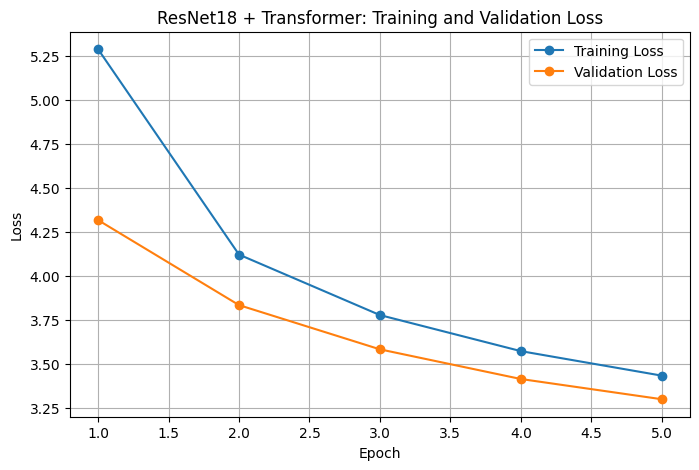

In [28]:
epochs = range(1, len(train_losses_res) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses_res, marker="o", label="Training Loss")
plt.plot(epochs, val_losses_res, marker="o", label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet18 + Transformer: Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

Both training and validation losses decrease over the five epochs, which indicates that the ResNet18 + Transformer model is learning from the image-caption pairs. Since the validation loss also decreases, there is no clear sign of overfitting in this short training run.

However, as with the baseline model, lower cross-entropy loss does not guarantee semantically accurate captions. The generated captions still need to be inspected qualitatively and evaluated with BLEU and ROUGE-L.

## Qualitative Examples: ResNet18 Greedy vs Beam Search

After training the ResNet18 model, generated captions are inspected qualitatively. This section compares greedy decoding and beam search on the same validation images.

Greedy decoding selects the most likely next word at each step, while beam search keeps several candidate captions and chooses the sequence with the best overall score.

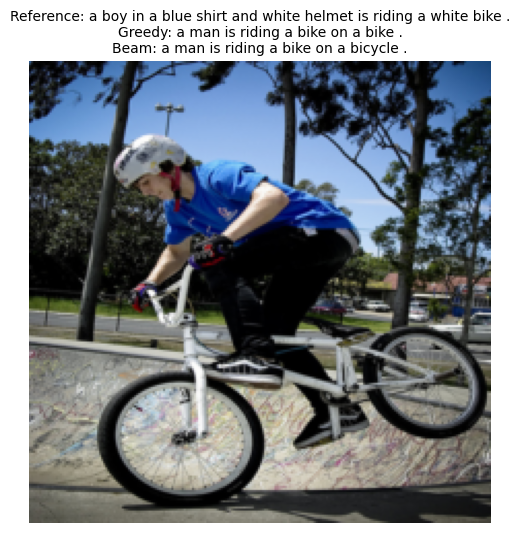

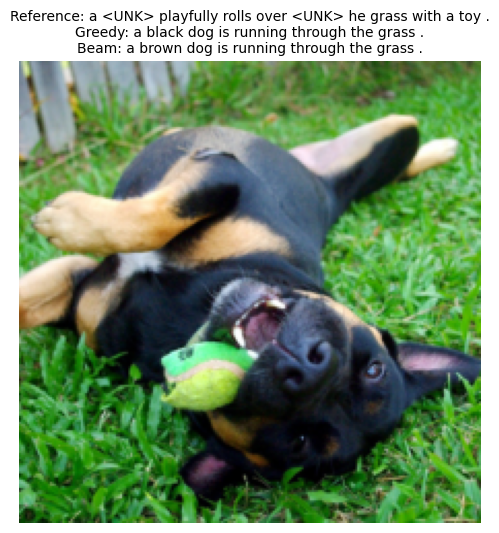

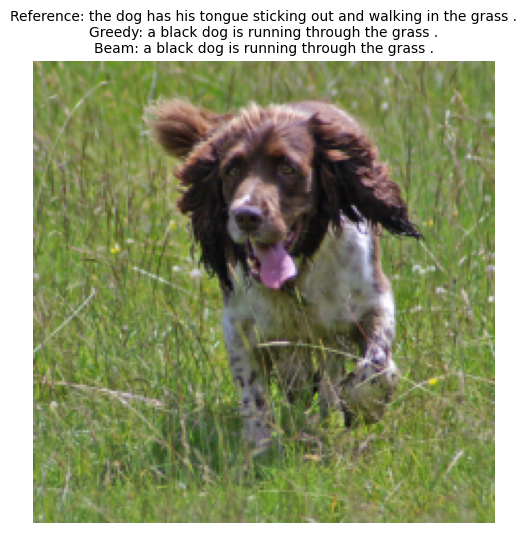

In [29]:
encoder.eval()
decoder.eval()

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

num_examples = 3

for i in range(num_examples):
    image, caption = val_dataset_res[i]

    greedy_caption = generate_caption(
        encoder=encoder,
        decoder=decoder,
        image=image,
        vocab=train_dataset_res.vocab,
        max_length=20
    )

    beam_caption = generate_caption_beam_search(
        encoder=encoder,
        decoder=decoder,
        image=image,
        vocab=train_dataset_res.vocab,
        beam_size=3,
        max_length=20,
        length_penalty=0.7
    )

    reference_caption = caption_tensor_to_tokens(
        caption,
        train_dataset_res.vocab
    )

    # generate_caption returns a string, while beam search returns a token list
    reference_text = " ".join(reference_caption)
    greedy_text = greedy_caption
    beam_text = " ".join(beam_caption)

    img = unnormalize_image(
        image,
        mean=imagenet_mean,
        std=imagenet_std
    ).permute(1, 2, 0).numpy()

    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.title(
        "Reference: " + reference_text + "\n" +
        "Greedy: " + greedy_text + "\n" +
        "Beam: " + beam_text,
        fontsize=10
    )
    plt.show()

The qualitative examples show that the ResNet18 model generates more coherent captions than the custom CNN baseline. Beam search can produce slightly more complete or more fluent sentences in some cases, but the improvement is not always obvious from individual examples. The captions still miss fine-grained details such as age, object attributes, actions, and specific visual context.

## Quantitative Evaluation: ResNet18 Greedy vs Beam Search

The ResNet18 model is evaluated using BLEU and ROUGE-L. Greedy decoding and beam search are compared using the same validation subset so that the effect of the decoding strategy can be measured directly.

In [30]:
resnet_greedy_metrics = evaluate_caption_metrics(
    encoder=encoder,
    decoder=decoder,
    val_dataset=val_dataset_res,
    vocab=train_dataset_res.vocab,
    max_samples=500,
    decoding_method="greedy"
)

resnet_beam_metrics = evaluate_caption_metrics(
    encoder=encoder,
    decoder=decoder,
    val_dataset=val_dataset_res,
    vocab=train_dataset_res.vocab,
    max_samples=500,
    decoding_method="beam",
    beam_size=3,
    length_penalty=0.7
)

decoding_comparison_df = pd.DataFrame({
    "ResNet18 + Greedy": resnet_greedy_metrics,
    "ResNet18 + Beam Search": resnet_beam_metrics
})

decoding_comparison_df

,ResNet18 + Greedy,ResNet18 + Beam Search
BLEU-1,0.338468,0.346534
BLEU-2,0.160914,0.171909
BLEU-3,0.082485,0.098424
BLEU-4,0.046030,0.058682
ROUGE-L,0.333470,0.335677


Beam search substantially improves all BLEU scores and ROUGE-L compared with greedy decoding. BLEU-1 increases from 0.0572 to 0.3465, and ROUGE-L increases from 0.0907 to 0.3357. This indicates that beam search finds captions with much higher lexical overlap with the reference captions.

However, the qualitative examples show that higher automatic scores do not always mean fully correct image descriptions. Beam search improves fluency and word overlap, but the generated captions can still miss fine-grained visual details.

## Overall Model Comparison

The final comparison summarises the effect of replacing the custom CNN encoder with a pretrained ResNet18 encoder and replacing greedy decoding with beam search.

In [31]:
full_comparison_df = pd.DataFrame({
    "Custom CNN + Greedy": custom_cnn_greedy_metrics,
    "ResNet18 + Greedy": resnet_greedy_metrics,
    "ResNet18 + Beam Search": resnet_beam_metrics
})

full_comparison_df

,Custom CNN + Greedy,ResNet18 + Greedy,ResNet18 + Beam Search
BLEU-1,0.339477,0.338468,0.346534
BLEU-2,0.155059,0.160914,0.171909
BLEU-3,0.076271,0.082485,0.098424
BLEU-4,0.042641,0.046030,0.058682
ROUGE-L,0.325185,0.333470,0.335677


The overall comparison shows that replacing the custom CNN encoder with a frozen pretrained ResNet18 encoder does not substantially improve greedy decoding performance. The Custom CNN + Greedy and ResNet18 + Greedy results are very similar across BLEU and ROUGE-L.

However, applying beam search to the ResNet18 model produces a large improvement in all automatic metrics. This suggests that, in the current setup, the decoding strategy has a stronger effect on lexical-overlap scores than replacing the custom CNN with a frozen ResNet18 encoder.

This result should still be interpreted carefully. Although beam search improves BLEU and ROUGE-L, qualitative examples show that the generated captions can still miss fine-grained visual details. Therefore, the improvement mainly indicates better word-level and phrase-level overlap, rather than fully accurate semantic image understanding.

### Main Findings

The results suggest that simply replacing the custom CNN encoder with a frozen ResNet18 encoder does not significantly improve greedy decoding performance. The Custom CNN + Greedy and ResNet18 + Greedy scores are almost identical.

The largest improvement comes from beam search decoding. This shows that the decoding strategy has a strong impact on BLEU and ROUGE-L scores. However, because these metrics mainly measure lexical overlap, the improvement should not be interpreted as perfect semantic understanding of the image.

Overall, the current model can generate fluent and sometimes relevant captions, but it still struggles with fine-grained visual details such as object attributes, actions, counting, and scene context.

## Error Analysis

Although beam search substantially improves BLEU and ROUGE-L scores, qualitative inspection is still necessary because automatic metrics mainly measure word overlap. Error analysis is used to identify common failure patterns in the generated captions, such as object errors, action errors, counting errors, scene errors, generic captions, and attribute errors.

This analysis focuses on the ResNet18 + Beam Search model because it achieves the best automatic scores among the tested settings. A subset of generated captions is manually inspected and assigned error categories.

For this analysis, the first 10 generated captions are manually labelled with one or more error categories.

In [32]:
def collect_caption_examples(
    encoder,
    decoder,
    val_dataset,
    vocab,
    num_examples=20,
    decoding_method="beam",
    beam_size=3,
    length_penalty=0.7
):
    """
    Collect generated captions and reference captions for qualitative error analysis.
    """
    examples = []

    encoder.eval()
    decoder.eval()

    for i in range(num_examples):
        image, caption = val_dataset[i]

        if decoding_method == "greedy":
            predicted_caption = generate_caption(
                encoder=encoder,
                decoder=decoder,
                image=image,
                vocab=vocab,
                max_length=20
            )
            prediction_text = predicted_caption

        elif decoding_method == "beam":
            predicted_caption = generate_caption_beam_search(
                encoder=encoder,
                decoder=decoder,
                image=image,
                vocab=vocab,
                beam_size=beam_size,
                max_length=20,
                length_penalty=length_penalty
            )
            prediction_text = " ".join(predicted_caption)

        else:
            raise ValueError("decoding_method must be 'greedy' or 'beam'.")

        reference_caption = caption_tensor_to_tokens(caption, vocab)
        reference_text = " ".join(reference_caption)

        examples.append({
            "index": i,
            "reference": reference_text,
            "prediction": prediction_text
        })

    return examples

In [33]:
beam_examples = collect_caption_examples(
    encoder=encoder,
    decoder=decoder,
    val_dataset=val_dataset_res,
    vocab=train_dataset_res.vocab,
    num_examples=20,
    decoding_method="beam",
    beam_size=3,
    length_penalty=0.7
)

beam_examples_df = pd.DataFrame(beam_examples)
beam_examples_df

,index,reference,prediction
0,0,a boy in a blue shirt and white helmet is ridi...,a man is riding a bike on a bicycle .
1,1,a <UNK> playfully rolls over <UNK> he grass wi...,a brown dog is running through the grass .
2,2,the dog has his tongue sticking out and walkin...,a black dog is running through the grass .
3,3,a tennis player moving for a shot .,a young boy wearing a red shirt is playing in ...
4,4,a man with an apron <UNK> <UNK> of corn .,a group of people are sitting on a <UNK> .
5,5,a white crane looks for food in the water .,a man in a blue shirt is standing on the water .
6,6,large brown dog jumps over red hurdle,a dog is running through the grass .
7,7,a man is on a sidewalk with a small animal on ...,a man in a red shirt is standing on a <UNK> .
8,8,a white dog races a brown dog in a field of gr...,a brown dog is running through the grass .
9,9,a person on a boat in a canal .,a man in a blue shirt is standing on the water .


In [34]:
# Manually label the first 10 examples for error analysis
beam_examples_df["error_type"] = ""
beam_examples_df["notes"] = ""

beam_examples_df.loc[0, "error_type"] = "Partially Correct; Attribute Error"
beam_examples_df.loc[0, "notes"] = "The model correctly describes a person riding a bike, but misses boy, blue shirt, white helmet, and white bike details."

beam_examples_df.loc[1, "error_type"] = "Partially Correct; Action Error; Object Error"
beam_examples_df.loc[1, "notes"] = "The model identifies a dog and grass, but predicts running instead of rolling and misses the toy."

beam_examples_df.loc[2, "error_type"] = "Partially Correct; Action Error; Attribute Error"
beam_examples_df.loc[2, "notes"] = "The model identifies a dog in grass, but predicts running instead of walking and gets the dog colour wrong."

beam_examples_df.loc[3, "error_type"] = "Object Error; Action Error; Scene Error"
beam_examples_df.loc[3, "notes"] = "The reference describes a tennis player, but the prediction describes a young boy in a red shirt."

beam_examples_df.loc[4, "error_type"] = "Object Error; Counting Error; Scene Error"
beam_examples_df.loc[4, "notes"] = "The reference describes a man with an apron and corn, but the prediction describes a group of people sitting."

beam_examples_df.loc[5, "error_type"] = "Object Error; Scene Error"
beam_examples_df.loc[5, "notes"] = "The reference describes a white crane in water, but the prediction describes a man standing in water."

beam_examples_df.loc[6, "error_type"] = "Partially Correct; Action Error; Scene Error"
beam_examples_df.loc[6, "notes"] = "The model identifies a dog, but misses the red hurdle and predicts running through grass instead of jumping."

beam_examples_df.loc[7, "error_type"] = "Generic Caption; Object Error; Attribute Error"
beam_examples_df.loc[7, "notes"] = "The prediction uses a generic man-in-red-shirt caption and misses the small animal."

beam_examples_df.loc[8, "error_type"] = "Partially Correct; Counting Error; Object Error"
beam_examples_df.loc[8, "notes"] = "The model identifies a dog in grass, but misses that two dogs are involved."

beam_examples_df.loc[9, "error_type"] = "Object Error; Action Error; Scene Error"
beam_examples_df.loc[9, "notes"] = "The reference describes a person on a boat in a canal, but the prediction describes a man standing on water."

In [35]:
error_counter = Counter()

for labels in beam_examples_df["error_type"]:
    if labels.strip() == "":
        continue

    for label in labels.split(";"):
        error_counter[label.strip()] += 1

error_summary_df = pd.DataFrame(
    error_counter.items(),
    columns=["Error Type", "Count"]
).sort_values(by="Count", ascending=False)

error_summary_df

,Error Type,Count
3,Object Error,7
2,Action Error,5
0,Partially Correct,5
4,Scene Error,5
1,Attribute Error,3
5,Counting Error,2
6,Generic Caption,1


The error summary shows that the most common failures are object errors, action errors, and scene errors. This means that the model often captures some high-level concepts, such as a person, dog, bike, or grass, but still struggles to describe the exact object, action, and context.

Several examples are partially correct. For instance, the model may correctly identify a dog in grass or a person riding a bike, but it often misses important attributes such as colour, age, object details, or the exact action. This explains why BLEU and ROUGE-L can improve while the captions are still not fully semantically accurate.

In [36]:
def show_error_examples(
    examples_df,
    val_dataset,
    num_examples=5
):
    """
    Display selected error analysis examples.
    """
    imagenet_mean = [0.485, 0.456, 0.406]
    imagenet_std = [0.229, 0.224, 0.225]

    for row_idx in range(min(num_examples, len(examples_df))):
        sample = examples_df.iloc[row_idx]
        image, _ = val_dataset[int(sample["index"])]

        img = unnormalize_image(
            image,
            mean=imagenet_mean,
            std=imagenet_std
        ).permute(1, 2, 0).numpy()

        plt.figure(figsize=(8, 6))
        plt.imshow(img)
        plt.axis("off")

        title = (
            f"Reference: {sample['reference']}\n"
            f"Prediction: {sample['prediction']}\n"
            f"Error Type: {sample['error_type']}"
        )

        plt.title(title, fontsize=9)
        plt.show()

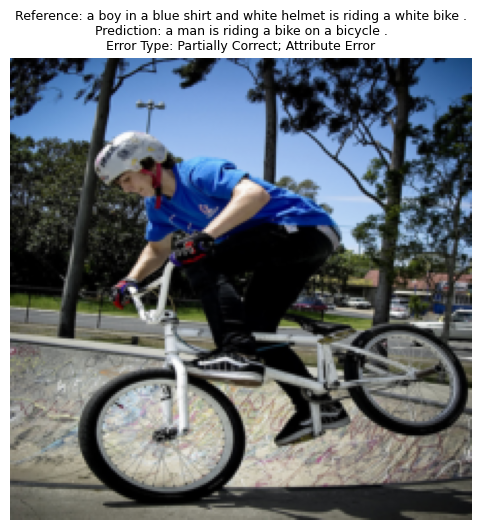

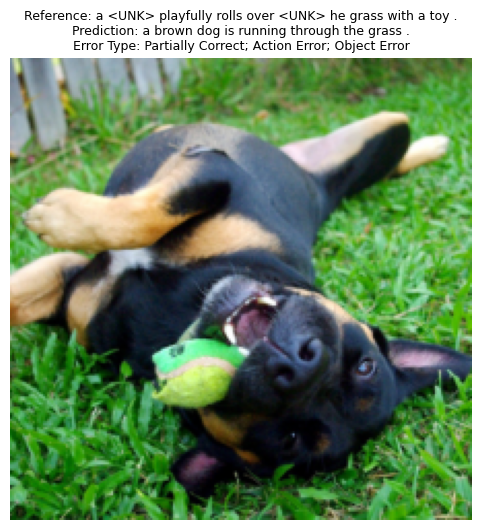

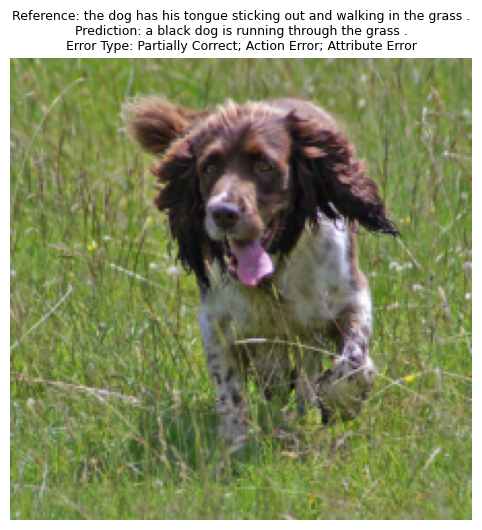

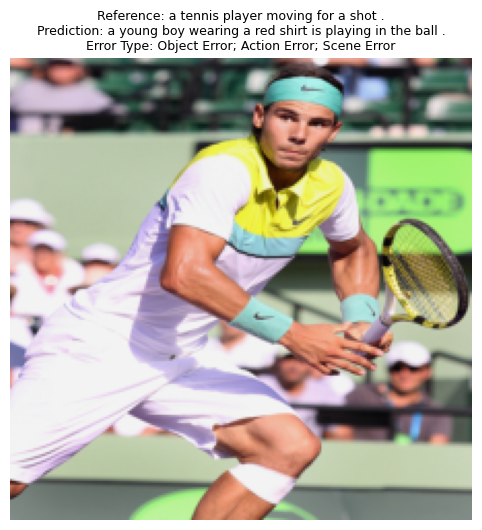

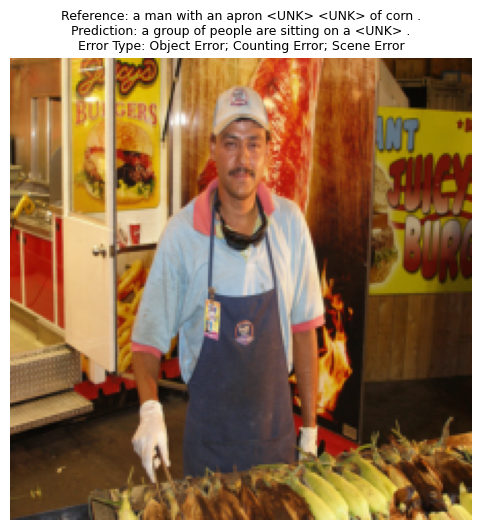

In [37]:
show_error_examples(
    examples_df=beam_examples_df,
    val_dataset=val_dataset_res,
    num_examples=5
)

The selected examples illustrate the gap between lexical overlap and semantic correctness. Some predictions are fluent and partially related to the image, but they often simplify the visual content into common caption templates. For example, dog images are frequently described as "a dog running through the grass", even when the reference describes rolling, jumping, or interacting with another object.

This suggests that the current model has learned common image-caption patterns, but its visual grounding is still limited.

## Limitations and Future Work

The main limitation of the current architecture is that the entire image is compressed into a single global feature vector before being passed to the Transformer decoder. This makes it difficult for the model to attend to different image regions and may explain errors in object recognition, counting, and action description.

Future improvements could include fine-tuning the last ResNet block, using spatial CNN feature maps instead of a single global vector, applying visual attention over image regions, reducing the vocabulary threshold to reduce `<UNK>` tokens, or training on a larger dataset such as MS-COCO.